<a href="https://colab.research.google.com/github/Eritriharyanto/klasifikasi-titanic-dataset/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [65]:
!pip install -q xgboost lightgbm catboost

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Load

In [66]:
df = pd.read_csv("Titanic-Dataset.csv")

print(df.shape)

df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# EDA

In [67]:
print("Jumlah Baris dan Kolom:")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

Jumlah Baris dan Kolom:
(891, 12)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [68]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Cek Missing Value**

In [69]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


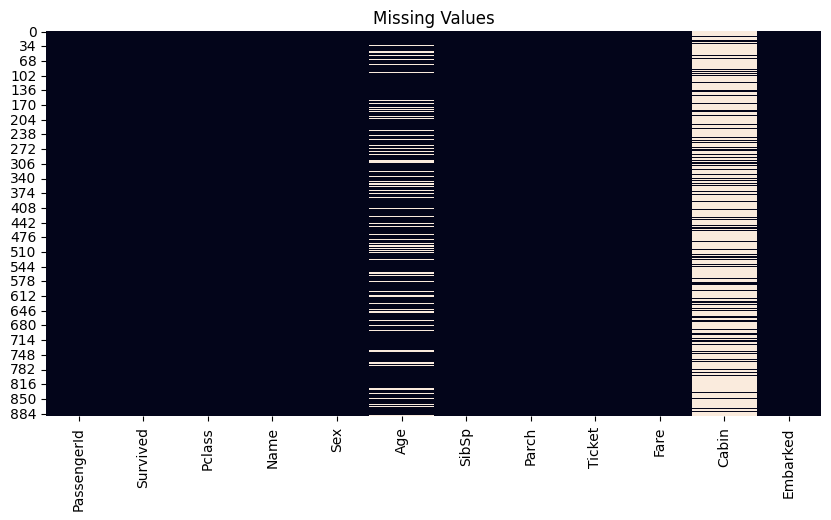

In [70]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

**Cek Balance & Distribusi Target**

In [71]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [72]:
print(df['Survived'].value_counts())

print("\nPersentase:")
print(df['Survived'].value_counts(normalize=True) * 100)

Survived
0    549
1    342
Name: count, dtype: int64

Persentase:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


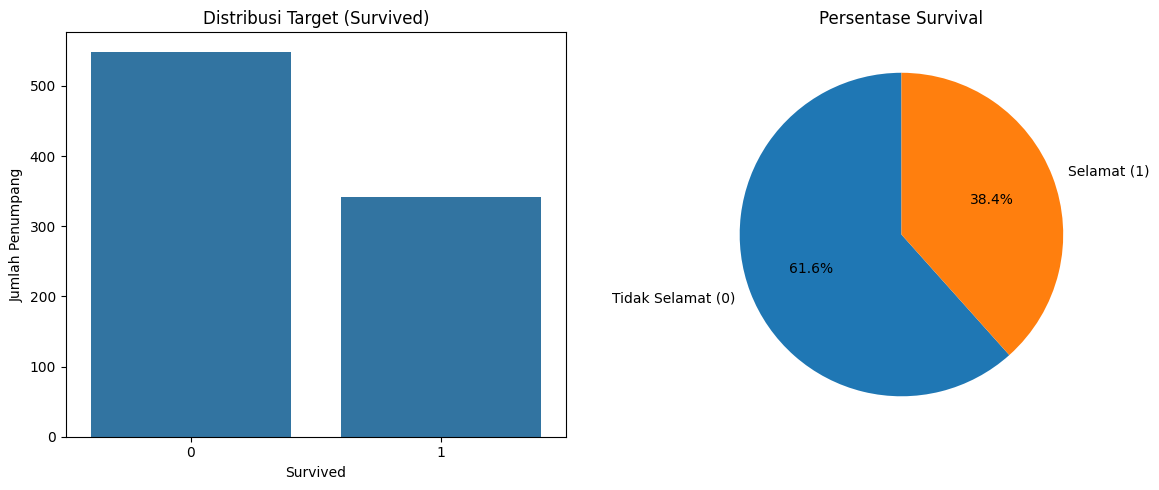

          Jumlah  Persentase (%)
Survived                        
0            549           61.62
1            342           38.38


In [73]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Jumlah data
survived_counts = df['Survived'].value_counts().sort_index()

# Persentase
survived_percent = (
    df['Survived']
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Countplot
sns.countplot(
    data=df,
    x='Survived',
    ax=ax[0]
)

ax[0].set_title('Distribusi Target (Survived)')
ax[0].set_xlabel('Survived')
ax[0].set_ylabel('Jumlah Penumpang')

# Pie Chart
ax[1].pie(
    survived_percent,
    labels=['Tidak Selamat (0)', 'Selamat (1)'],
    autopct='%1.1f%%',
    startangle=90
)

ax[1].set_title('Persentase Survival')

plt.tight_layout()
plt.show()

# Tampilkan jumlah dan persentase
summary = pd.DataFrame({
    'Jumlah': survived_counts,
    'Persentase (%)': survived_percent.round(2)
})

print(summary)

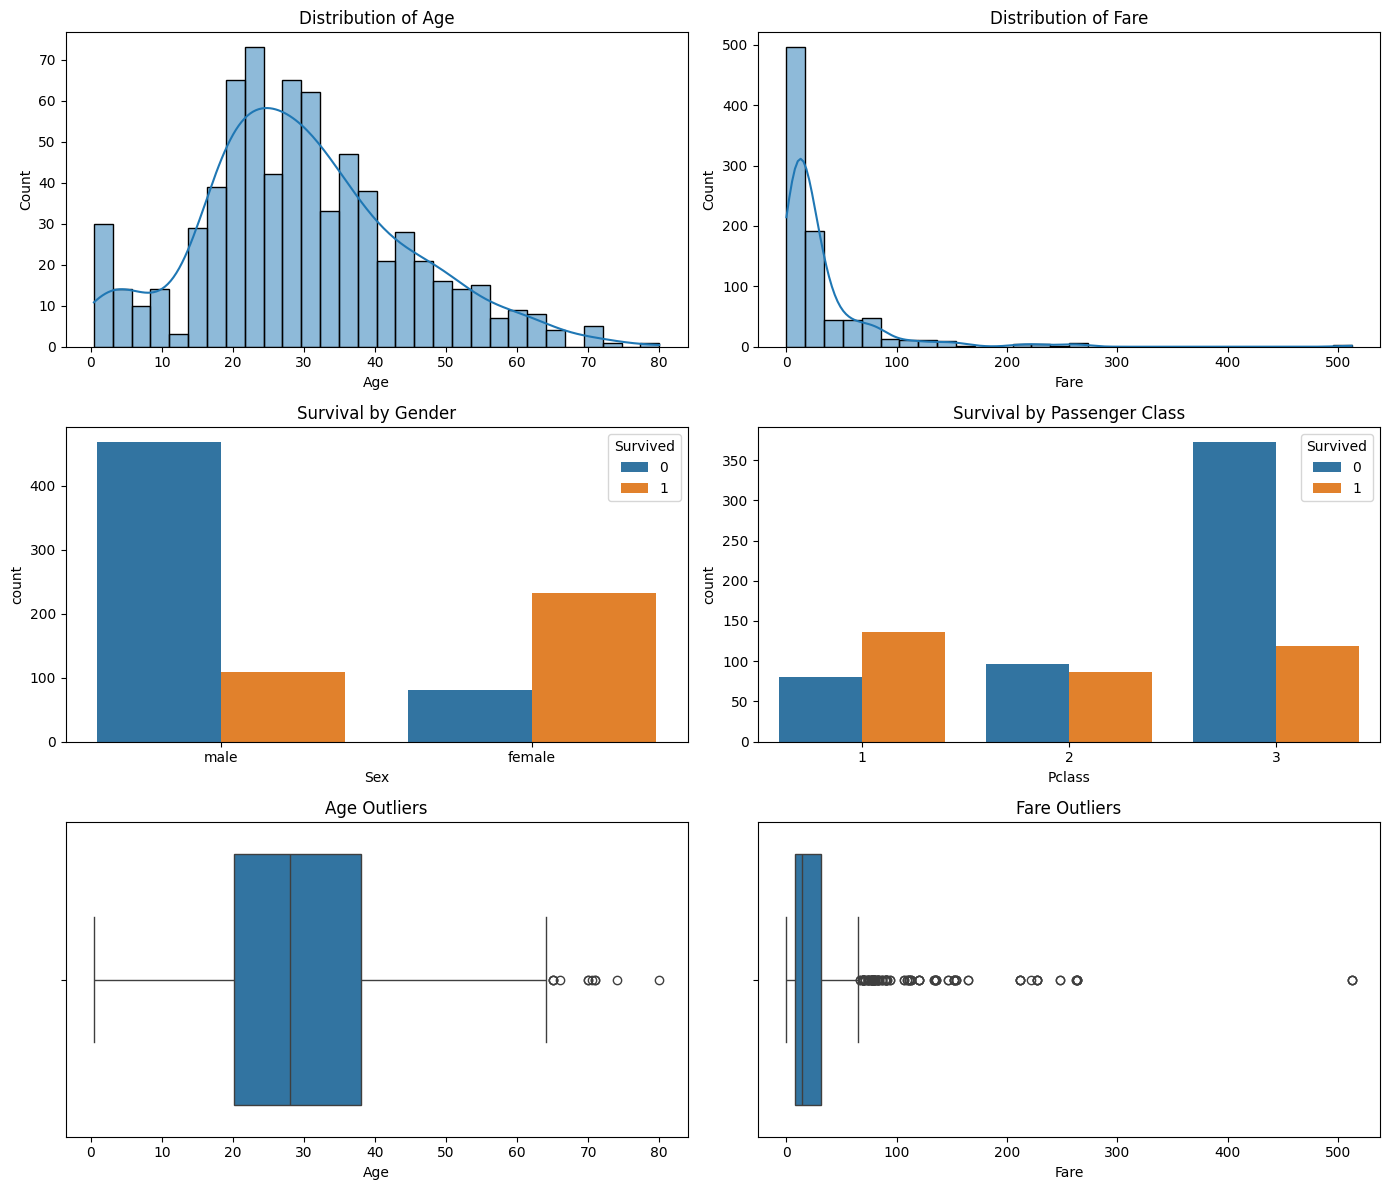

In [74]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Distribusi Age
sns.histplot(
    df['Age'],
    bins=30,
    kde=True,
    ax=axes[0,0]
)
axes[0,0].set_title('Distribution of Age')

# Distribusi Fare
sns.histplot(
    df['Fare'],
    bins=30,
    kde=True,
    ax=axes[0,1]
)
axes[0,1].set_title('Distribution of Fare')

# Survival berdasarkan Gender
sns.countplot(
    data=df,
    x='Sex',
    hue='Survived',
    ax=axes[1,0]
)
axes[1,0].set_title('Survival by Gender')

# Survival berdasarkan Pclass
sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived',
    ax=axes[1,1]
)
axes[1,1].set_title('Survival by Passenger Class')

# Outlier Age
sns.boxplot(
    x=df['Age'],
    ax=axes[2,0]
)
axes[2,0].set_title('Age Outliers')

# Outlier Fare
sns.boxplot(
    x=df['Fare'],
    ax=axes[2,1]
)
axes[2,1].set_title('Fare Outliers')

plt.tight_layout()
plt.show()

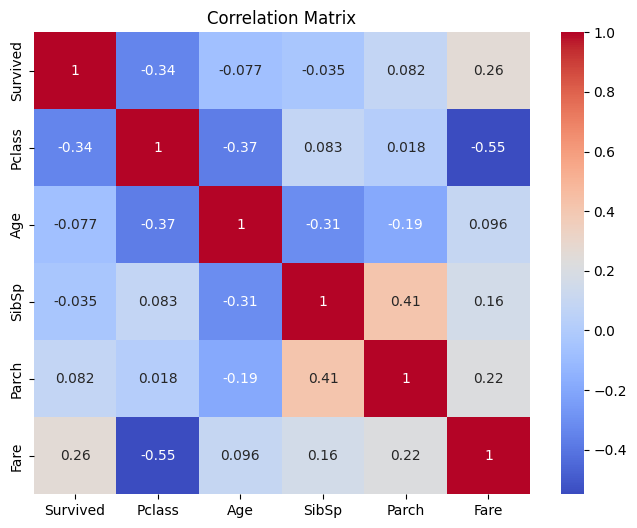

In [75]:
numeric_cols = [
    'Survived',
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

# Handel Missing Value

In [76]:
# Age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

# Cabin
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['CabinDeck'] = df['Cabin'].str[0]

# Feacture Engineering

In [77]:
df['Title'] = df['Name'].str.extract(
    ' ([A-Za-z]+)\.',
    expand=False
)

df['CabinDeck'] = df['Cabin'].str[0]

df['TicketFreq'] = (
    df.groupby('Ticket')['Ticket']
    .transform('count')
)

df['FamilySize'] = (
    df['SibSp']
    + df['Parch']
    + 1
)

df['IsAlone'] = (
    df['FamilySize'] == 1
).astype(int)

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_2822/2702289791.py:2: SyntaxWarning: invalid escape sequence '\.'
  ' ([A-Za-z]+)\.',


In [78]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [79]:
df['FamilySize'] = (
    df['SibSp'] +
    df['Parch'] + 1
)

df['IsAlone'] = (
    df['FamilySize'] == 1
).astype(int)

# Cleaning

In [80]:
rare_titles = [
    'Dr','Rev','Col',
    'Major','Lady',
    'Countess','Sir',
    'Capt','Don',
    'Jonkheer'
]

df['Title'] = df['Title'].replace(
    rare_titles,
    'Rare'
)

# Encoding

In [81]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(
    df['Sex']
)

df['Embarked'] = le.fit_transform(
    df['Embarked']
)

df['Title'] = le.fit_transform(
    df['Title']
)

df['CabinDeck'] = le.fit_transform(
    df['CabinDeck']
)

**Hapus kolom**

In [82]:
df.drop(
    columns=[
        'Name',
        'Ticket',
        'Cabin'
    ],
    inplace=True
)

In [83]:
df.drop(columns=['PassengerId'], inplace=True)

In [84]:
X = df.drop('Survived', axis=1)

y = df['Survived']

# Train Test Split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Train**

In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [87]:
models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),

    "LightGBM":
    LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),

    "CatBoost":
    CatBoostClassifier(
        verbose=0,
        random_state=42
    )
}

In [88]:
results = []

for name, model in models.items():

    if name == "Logistic Regression":

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    results.append(
        [name, acc]
    )

    print("="*50)
    print(name)
    print("="*50)

    print(
        f"Accuracy : {acc:.4f}"
    )

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

Logistic Regression
Accuracy : 0.8101
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

Random Forest
Accuracy : 0.7598
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       110
           1       0.70      0.67      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179

XGBoost
Accuracy : 0.8045
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       110
           1       0.75      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.7

In [89]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
0,Logistic Regression,0.810056
2,XGBoost,0.804469
4,CatBoost,0.798883
3,LightGBM,0.765363
1,Random Forest,0.759777


In [90]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

cv_results = []

for name, model in models.items():

    # Logistic Regression perlu scaling
    if name == "Logistic Regression":

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        scores = cross_val_score(
            pipe,
            X,
            y,
            cv=5,
            scoring='accuracy'
        )

    else:

        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring='accuracy'
        )

    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std()
    })

    print("=" * 50)
    print(name)
    print("=" * 50)
    print(f"Fold Accuracy : {scores}")
    print(f"Mean Accuracy : {scores.mean():.4f}")
    print(f"Std Accuracy  : {scores.std():.4f}")
    print()

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by='CV Mean Accuracy',
    ascending=False
)

cv_results_df

Logistic Regression
Fold Accuracy : [0.7877095  0.79213483 0.76966292 0.78651685 0.82022472]
Mean Accuracy : 0.7912
Std Accuracy  : 0.0164

Random Forest
Fold Accuracy : [0.7877095  0.79775281 0.86516854 0.76966292 0.83146067]
Mean Accuracy : 0.8104
Std Accuracy  : 0.0340

XGBoost
Fold Accuracy : [0.82122905 0.80898876 0.85955056 0.79775281 0.85393258]
Mean Accuracy : 0.8283
Std Accuracy  : 0.0245

LightGBM
Fold Accuracy : [0.79329609 0.79213483 0.87078652 0.79775281 0.85393258]
Mean Accuracy : 0.8216
Std Accuracy  : 0.0338

CatBoost
Fold Accuracy : [0.84357542 0.79213483 0.83707865 0.80337079 0.85955056]
Mean Accuracy : 0.8271
Std Accuracy  : 0.0253



,Model,CV Mean Accuracy,CV Std
2,XGBoost,0.828291,0.024453
4,CatBoost,0.827142,0.025336
3,LightGBM,0.821581,0.033772
1,Random Forest,0.810351,0.033993
0,Logistic Regression,0.791250,0.016378


In [96]:
for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

In [97]:
if name == "Logistic Regression":

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

In [98]:
for name, model in models.items():

    if name == "Logistic Regression":

        train_acc = model.score(
            X_train_scaled,
            y_train
        )

        test_acc = model.score(
            X_test_scaled,
            y_test
        )

    else:

        train_acc = model.score(
            X_train,
            y_train
        )

        test_acc = model.score(
            X_test,
            y_test
        )

    print(f"{name}")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print("-"*40)

Logistic Regression
Train Accuracy : 0.8034
Test Accuracy  : 0.8101
----------------------------------------
Random Forest
Train Accuracy : 0.9846
Test Accuracy  : 0.7598
----------------------------------------
XGBoost
Train Accuracy : 0.9761
Test Accuracy  : 0.8045
----------------------------------------
LightGBM
Train Accuracy : 0.9663
Test Accuracy  : 0.7654
----------------------------------------
CatBoost
Train Accuracy : 0.9270
Test Accuracy  : 0.7989
----------------------------------------


# Evaluasi

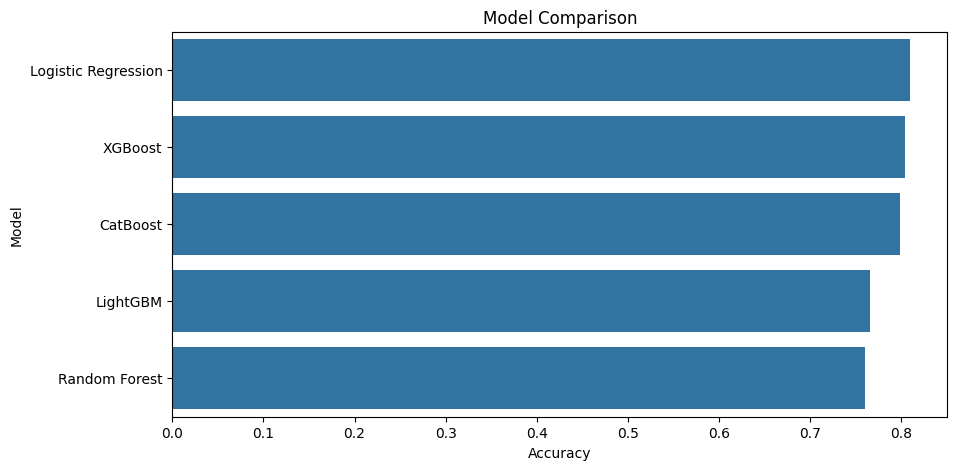

In [91]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model'
)

plt.title("Model Comparison")
plt.show()

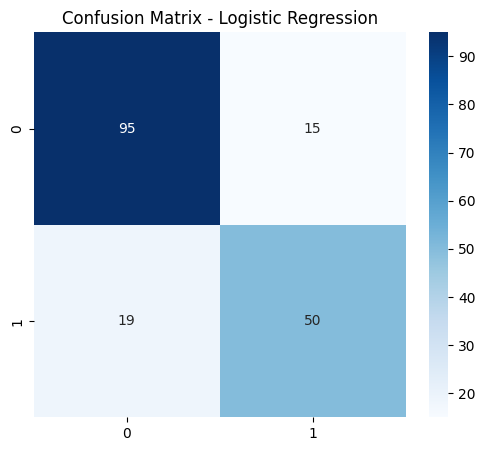

In [92]:
if best_model_name == "Logistic Regression":

    y_pred = best_model.predict(
        X_test_scaled
    )

else:

    y_pred = best_model.predict(
        X_test
    )

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

**Feacture Importance**

In [93]:
if hasattr(
    best_model,
    'feature_importances_'
):

    importance = pd.DataFrame({

        'Feature': X.columns,

        'Importance':
        best_model.feature_importances_

    })

    importance = importance.sort_values(
        by='Importance',
        ascending=False
    )

    plt.figure(
        figsize=(10,6)
    )

    sns.barplot(
        data=importance,
        x='Importance',
        y='Feature'
    )

    plt.title(
        f"Feature Importance - {best_model_name}"
    )

    plt.show()

**ROC**

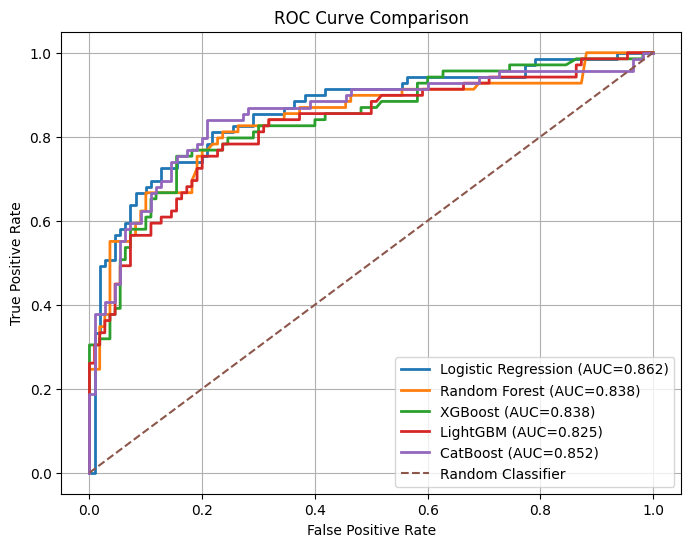

In [94]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    if name == "Logistic Regression":

        y_prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        y_prob = model.predict_proba(
            X_test
        )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend(
    loc='lower right'
)

plt.grid(True)

plt.show()